# Lukemia - Analiza komórek nowotworowych (CNN)

Przedmiot: Analiza danych multimedialnych

Prowadzący: Łukasz Jeleń

Autorzy: Szymon Drapiński, Maciej Adamski, Dominik Ochej, Jakub Cegłowski

Grupa: SliUM2m G

## Wstęp

Celem projektu jest rozróżnianie zdjęć mikroskopowych białych krwinek pod kątem zmian nowotworowych (białaczki) przy użyciu konwolucyjnej sieci neuronowej (CNN). 
W poprzedniej wersji projektu (plik `main.ipynb`, dane w `data/v1`) klasyfikacja opierała się na ręcznie projektowanych cechach morfologicznych i kolorystycznych. 
W tej wersji wykorzystujemy transfer learning (VGG16) na znacznie większym zbiorze danych pogrupowanym w foldy.

## Opis danych wykorzystywanych w projekcie

Dane znajdują się w katalogu **`/data`** w podziale na trzy foldy: `fold_0`, `fold_1`, `fold_2`. 
Każdy fold zawiera dwa podkatalogi klas:

- **`all`** – komórki wykazujące zmiany nowotworowe (białaczka, klasa pozytywna = 1),
- **`hem`** – komórki zdrowe (klasa negatywna = 0).

### Podział na zbiory

- **Trening:** `data/fold_0/fold_0` (klasy `all` + `hem`)
- **Walidacja:** `data/fold_2/fold_2` (klasy `all` + `hem`)

Fold 1 pozostaje jako rezerwowy zbiór testowy.

## Importy

In [1]:
#pip install -r requirements.txt

In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Wczytanie danych

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASS_NAMES = ["hem", "all"]  # hem=0 (zdrowe), all=1 (białaczka)

TRAIN_DIR = os.path.join("data", "fold_0", "fold_0")
VAL_DIR = os.path.join("data", "fold_2", "fold_2")

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Klasy (w kolejności etykiet):", train_ds.class_names)

Found 4794 files belonging to 2 classes.
Found 4914 files belonging to 2 classes.
Klasy (w kolejności etykiet): ['hem', 'all']


### Preprocessing i prefetch

Na kazdy obraz nakladamy dwa etapy obrobki:

1. **Reinhard stain normalization** - ujednolica barwienie preparatow (rozne foldy moga miec rozne odcienie). W przestrzeni LAB przesuwamy srednia i odchylenie kazdego obrazu do wartosci referencyjnych wyliczonych z wybranego obrazu treningowego. Dzieki temu siec nie uczy sie roznic w barwieniu jako cechy klasy.
2. **CLAHE na kanale L (LAB)** - lokalna normalizacja kontrastu zachowujaca kolor. Uwydatnia strukture jadra komorki bez tracenia informacji barwnej (w przeciwienstwie do CLAHE na szarosci z poprzedniej wersji projektu).

Nastepnie dane przepuszczamy przez `preprocess_input` VGG16 (RGB->BGR + odejmowanie sredniej ImageNet) i korzystamy z `prefetch`/`cache`.

**Wazne zmiany w pipeline (poprawa wynikow):**
- Kolejnosc operacji: `cache().shuffle(reshuffle_each_iteration=True).prefetch()` - dzieki temu kazda epoka widzi inny porzadek probek (poprzednio zafiksowany po pierwszym przejsciu).
- **Augmentacja** zostala dodana jako warstwy modelu Keras (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`) - tylko transformacje geometryczne, ktore dzialaja poprawnie na danych po `preprocess_input`. Kazda epoka widzi rozne warianty obrazu, co znacznie redukuje przeuczanie i poprawia generalizacje, zwlaszcza dla mniej licznej klasy `hem`.
- Wagi klas (`class_weight`) kompensuja niezbalansowanie zbioru (~68% all vs 32% hem).

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

# ---- Referencja dla Reinhard stain normalization ----
# Bierzemy pierwszy obraz z klasy 'all' jako obraz referencyjny barwienia.
_ref_files = sorted(os.listdir(os.path.join(TRAIN_DIR, "all")))
_ref_path = os.path.join(TRAIN_DIR, "all", _ref_files[0])
_ref_bgr = cv2.imread(_ref_path)
_ref_rgb = cv2.cvtColor(_ref_bgr, cv2.COLOR_BGR2RGB)
_ref_lab = cv2.cvtColor(_ref_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
REF_MEAN = _ref_lab.reshape(-1, 3).mean(axis=0)
REF_STD = _ref_lab.reshape(-1, 3).std(axis=0) + 1e-6
print(f"Obraz referencyjny: {_ref_files[0]}")
print(f"REF_MEAN (LAB): {REF_MEAN}")
print(f"REF_STD  (LAB): {REF_STD}")

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def _stain_norm_clahe(img_uint8):
    """Reinhard stain normalization + CLAHE na kanale L."""
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB).astype(np.float32)
    # Reinhard: dopasowanie sredniej i odchylenia do referencji
    mean = lab.reshape(-1, 3).mean(axis=0)
    std = lab.reshape(-1, 3).std(axis=0) + 1e-6
    lab = (lab - mean) * (REF_STD / std) + REF_MEAN
    lab = np.clip(lab, 0, 255).astype(np.uint8)
    # CLAHE tylko na kanale L
    l, a, b = cv2.split(lab)
    l = _clahe.apply(l)
    lab = cv2.merge([l, a, b])
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return rgb


def _preprocess_one(img):
    img = tf.cast(img, tf.uint8)
    out = tf.numpy_function(_stain_norm_clahe, [img], tf.uint8)
    out.set_shape(img.shape)
    return tf.cast(out, tf.float32)


def _preprocess_batch(x, y):
    x = tf.map_fn(_preprocess_one, x, fn_output_signature=tf.float32)
    return x, y


def prepare(ds, training=False):
    ds = ds.map(_preprocess_batch, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        # reshuffle_each_iteration=True - kazda epoka widzi inna kolejnosc
        ds = ds.shuffle(buffer_size=1024, seed=42, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)


train_ds_prepared = prepare(train_ds, training=True)
val_ds_prepared = prepare(val_ds, training=False)

# ---- Wagi klas ----
n_hem = len(os.listdir(os.path.join(TRAIN_DIR, "hem")))
n_all = len(os.listdir(os.path.join(TRAIN_DIR, "all")))
total = n_hem + n_all
class_weight = {
    0: total / (2 * n_hem),  # hem
    1: total / (2 * n_all),  # all
}
print(f"Liczebnosc treningu: hem={n_hem}, all={n_all}")
print(f"class_weight: {class_weight}")

Obraz referencyjny: UID_11_10_1_all.bmp
REF_MEAN (LAB): [ 11.881037 134.04367  123.59756 ]
REF_STD  (LAB): [24.314089 12.193213  8.931272]
Liczebnosc treningu: hem=2397, all=2397
class_weight: {0: 1.0, 1: 1.0}


## Wizualizacja etapow obrobki danych

Aby wizualnie sprawdzic co robi pipeline z obrazami, zapisujemy do `output/preprocessing_stages/` oraz wyswietlamy po kilka przykladowych obrazow z kazdej klasy po kazdym etapie:

1. **resized** - po wczytaniu i przeskalowaniu do 128x128,
2. **stain_norm** - po Reinhard stain normalization (LAB),
3. **clahe** - po CLAHE na kanale L,
4. **channels** - rozlozenie na kanaly R, G, B (gotowe wejscie zanim pojdzie do `preprocess_input`).

Krok `preprocess_input` (odejmowanie sredniej ImageNet + RGB->BGR) nie jest wizualizowany bo daje wartosci ujemne i w BGR - nie nadaje sie do wyswietlenia jako obraz.

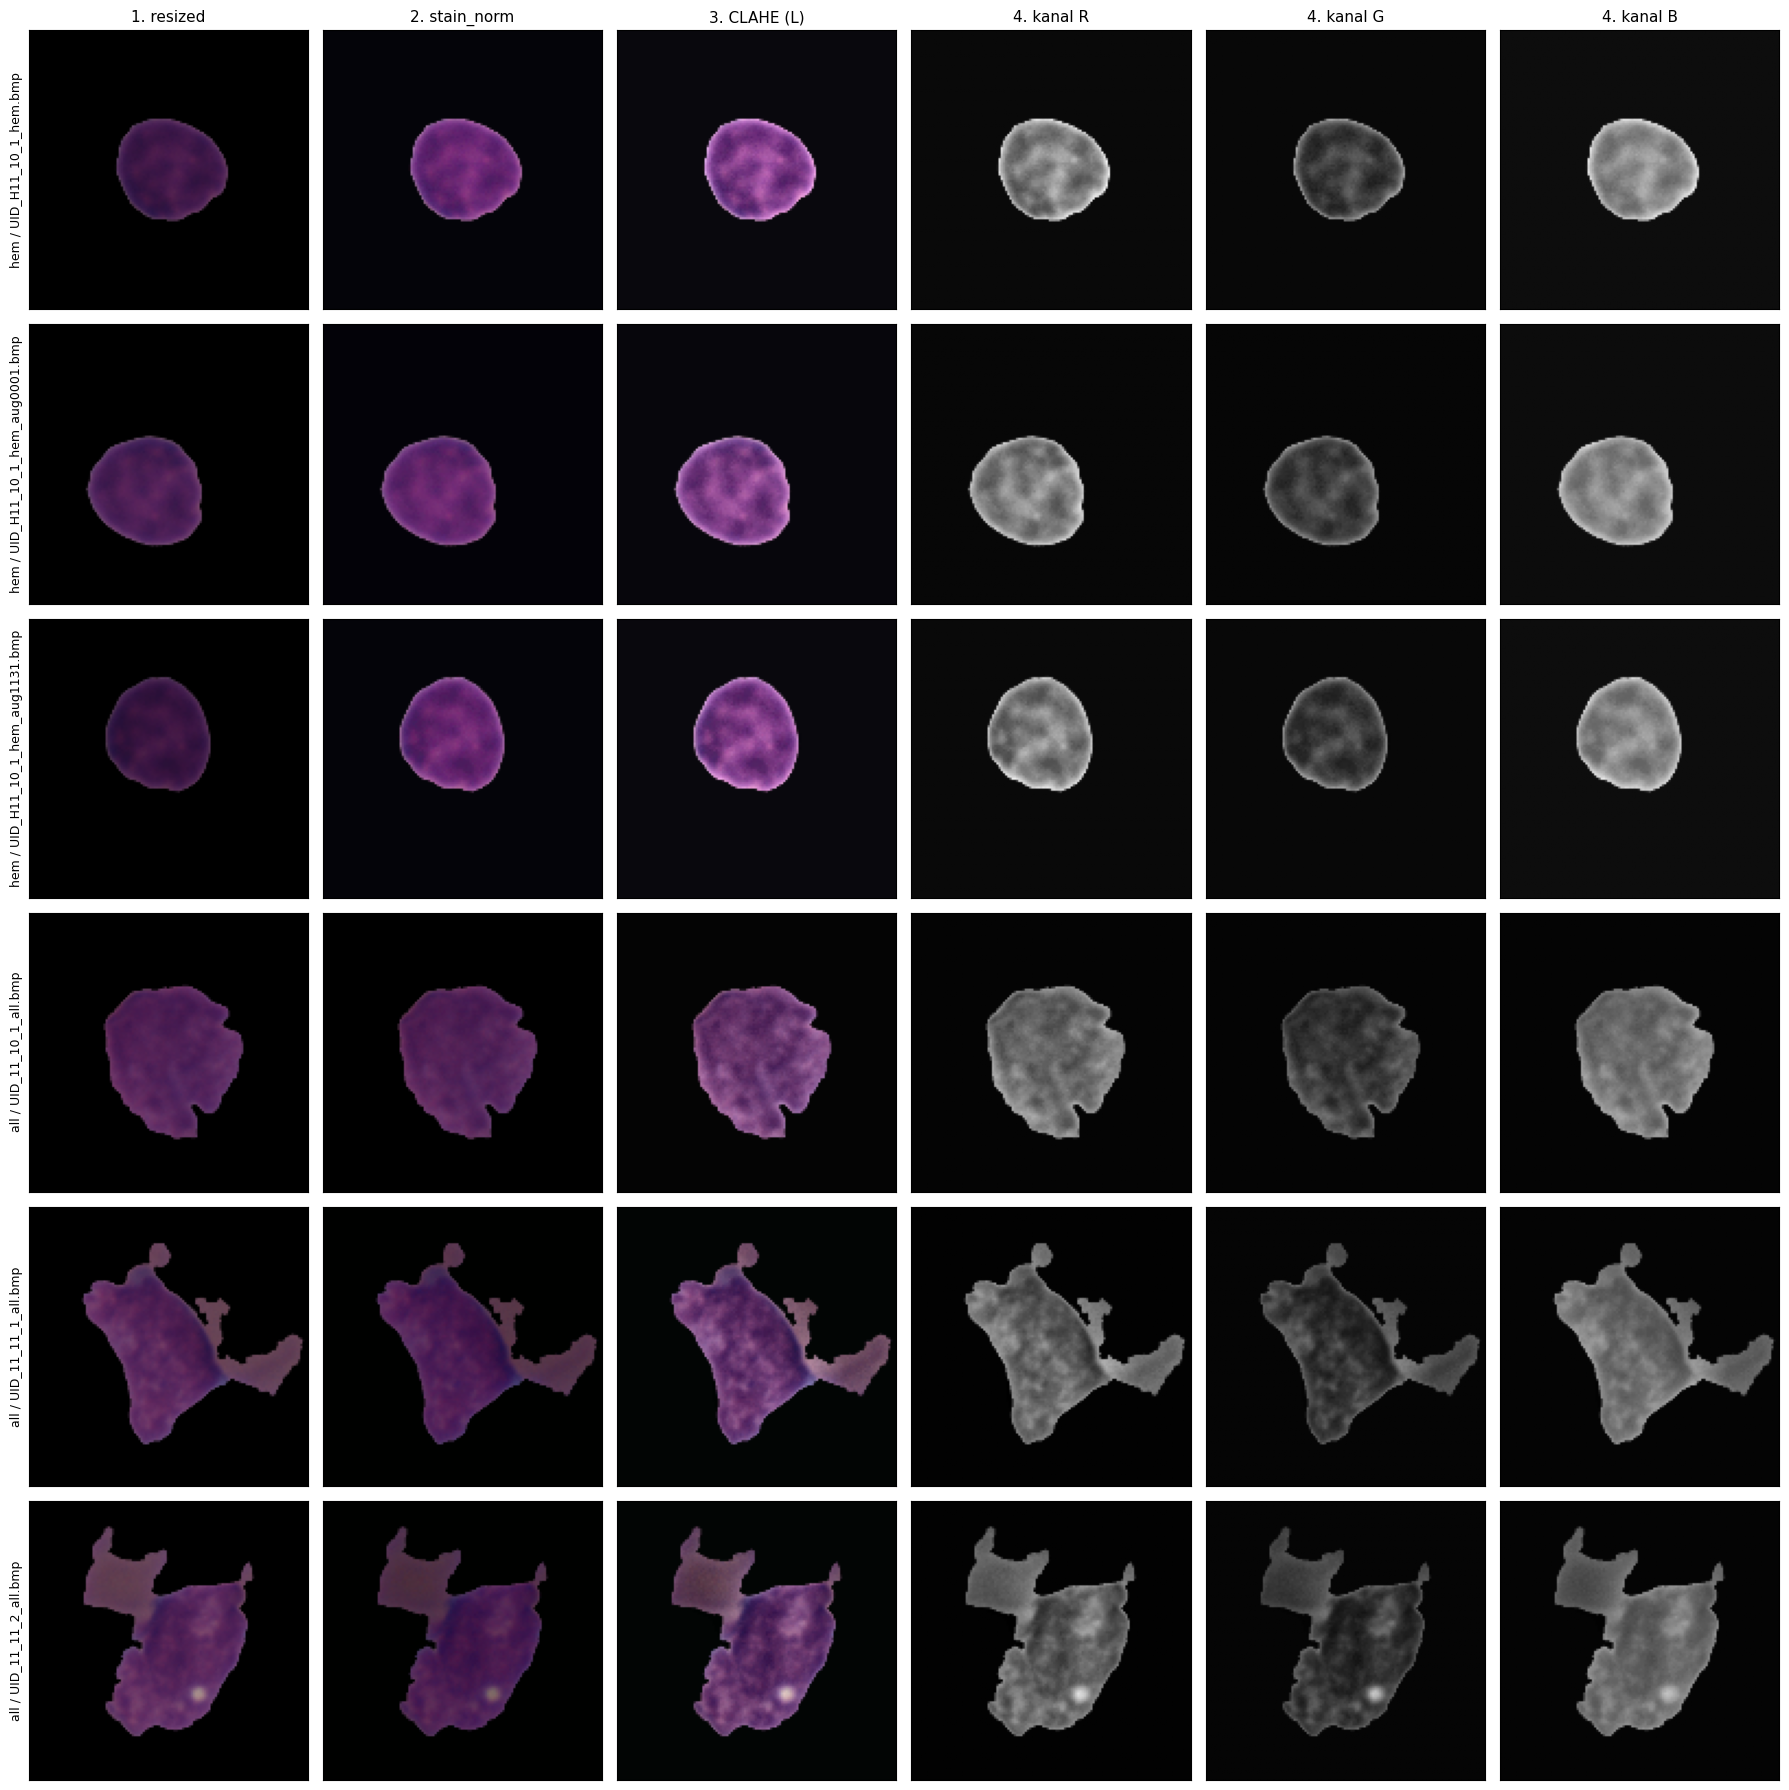

Zapisano 36 plikow + podglad do: output\preprocessing_stages


In [5]:
STAGES_DIR = os.path.join("output", "preprocessing_stages")
os.makedirs(STAGES_DIR, exist_ok=True)

N_SAMPLES_PER_CLASS = 3


def _load_and_resize(path, size=IMG_SIZE):
    bgr = cv2.imread(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return cv2.resize(rgb, size)


def _apply_stain_norm(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    mean = lab.reshape(-1, 3).mean(axis=0)
    std = lab.reshape(-1, 3).std(axis=0) + 1e-6
    lab = (lab - mean) * (REF_STD / std) + REF_MEAN
    return np.clip(lab, 0, 255).astype(np.uint8)  # w LAB


def _apply_clahe_on_l(lab_uint8):
    l, a, b = cv2.split(lab_uint8)
    l = _clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def _save_rgb(path, rgb):
    cv2.imwrite(path, cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


samples = []
for cls in ["hem", "all"]:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = sorted(os.listdir(cls_dir))[:N_SAMPLES_PER_CLASS]
    for f in files:
        samples.append((cls, f, os.path.join(cls_dir, f)))

rows = []
for cls, fname, fpath in samples:
    base = f"{cls}_{os.path.splitext(fname)[0]}"

    resized = _load_and_resize(fpath)
    lab_norm = _apply_stain_norm(resized)
    stain_rgb = cv2.cvtColor(lab_norm, cv2.COLOR_LAB2RGB)
    clahe_rgb = _apply_clahe_on_l(lab_norm)
    R, G, B = cv2.split(clahe_rgb)

    _save_rgb(os.path.join(STAGES_DIR, f"{base}_1_resized.png"), resized)
    _save_rgb(os.path.join(STAGES_DIR, f"{base}_2_stain_norm.png"), stain_rgb)
    _save_rgb(os.path.join(STAGES_DIR, f"{base}_3_clahe.png"), clahe_rgb)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_R.png"), R)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_G.png"), G)
    cv2.imwrite(os.path.join(STAGES_DIR, f"{base}_4_channel_B.png"), B)

    rows.append((f"{cls} / {fname}", [resized, stain_rgb, clahe_rgb, R, G, B]))

col_titles = ["1. resized", "2. stain_norm", "3. CLAHE (L)", "4. kanal R", "4. kanal G", "4. kanal B"]
fig, axes = plt.subplots(len(rows), 6, figsize=(18, 3 * len(rows)))
if len(rows) == 1:
    axes = np.array([axes])

for i, (title, imgs) in enumerate(rows):
    for j, img in enumerate(imgs):
        ax = axes[i, j]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(img)
        if i == 0:
            ax.set_title(col_titles[j], fontsize=11)
        if j == 0:
            ax.set_ylabel(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(STAGES_DIR, "_overview.png"), dpi=100, bbox_inches="tight")
plt.show()

print(f"Zapisano {len(samples) * 6} plikow + podglad do: {STAGES_DIR}")

## Budowa modelu CNN (transfer learning - VGG16)

Architektura sklada sie z trzech blokow:

1. **Augmentacja danych** (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomTranslation`) - aktywna tylko podczas treningu, generuje rozne warianty kazdego obrazu w kazdej epoce. Komorki krwi nie maja wyrozniajacej orientacji wiec rotacje/odbicia sa naturalne i bardzo skuteczne.
2. **Baza VGG16** pre-trenowana na ImageNet, w stage 1 calkowicie zamrozona (uczymy tylko glowe), w stage 2 odmrazamy ostatni blok konwolucyjny (`block5`) do fine-tuningu.
3. **Glowa klasyfikacyjna**: `GlobalAveragePooling2D` -> `BatchNormalization` -> `Dropout(0.5)` -> `Dense(128, ReLU)` -> `BatchNormalization` -> `Dropout(0.3)` -> `Dense(1, sigmoid)`. BatchNorm stabilizuje uczenie, wieksze dropout walczy z przeuczaniem.

Metryki: oprocz `accuracy` monitorujemy **AUC**, **Precision** i **Recall** - to wlasciwe metryki przy niezbalansowanych zbiorach. Loss to wazone `binary_crossentropy` (przez `class_weight`).

In [6]:
# ---- Augmentacja (warstwy Keras, aktywne tylko w trybie trening) ----
# Tylko transformacje geometryczne - dzialaja poprawnie na danych po preprocess_input
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=42),
    layers.RandomRotation(0.2, seed=42),       # +/- 20% z 360 stopni = +/- 72 stopnie
    layers.RandomZoom(0.15, seed=42),          # +/- 15% zoom
    layers.RandomTranslation(0.1, 0.1, seed=42),
], name="augmentation")

# ---- Baza VGG16 (zamrozona w stage 1) ----
base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model.trainable = False  # stage 1: tylko glowa

# ---- Pelny model ----
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)  # training=False dla BN warstw VGG16
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs, name="vgg16_leukemia")

METRICS = [
    "accuracy",
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=METRICS,
)

model.summary()

Model: "vgg16_leukemia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,783,041 (56.39 MB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 14,715,968 (56.14 MB)

## Trening

Trening prowadzony jest dwuetapowo:

- **Stage 1 - "warm-up" glowy** (do 15 epok, LR=1e-3): VGG16 calkowicie zamrozone, uczy sie tylko nowa glowa. Dzieki temu duze gradienty z losowo zainicjalizowanej glowy nie psuja pretrenowanych wag VGG16. EarlyStopping monitoruje `val_auc`.
- **Stage 2 - fine-tuning bloku 5** (do 15 epok, LR=1e-5): odmrazamy ostatni blok konwolucyjny VGG16 i uczymy z bardzo malym LR. Wczesniejsze warstwy (low-level features jak krawedzie/tekstury) zostaja zamrozone. To pozwala dostosowac wysokopoziomowe cechy do specyfiki obrazow mikroskopowych komorek krwi.

Callbacki: `EarlyStopping(patience=5)`, `ReduceLROnPlateau` (zmniejsza LR gdy `val_loss` przestaje spadac), `ModelCheckpoint` (zapisuje najlepszy model wedlug `val_auc`).

In [7]:
os.makedirs("output", exist_ok=True)

BEST_MODEL_PATH = os.path.join("output", "best_model.keras")


def make_callbacks(monitor="val_auc", mode="max"):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor, mode=mode,
            patience=5, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min",
            factor=0.3, patience=2, min_lr=1e-7, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=BEST_MODEL_PATH,
            monitor=monitor, mode=mode,
            save_best_only=True, verbose=1,
        ),
    ]


# ============================================================
# STAGE 1 - trening glowy (VGG16 zamrozone)
# ============================================================
print("=" * 60)
print("STAGE 1: trening glowy (baza zamrozona)")
print("=" * 60)

EPOCHS_HEAD = 15

history_head = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks()
)

# ============================================================
# STAGE 2 - fine-tuning bloku 5 VGG16
# ============================================================
print("=" * 60)
print("STAGE 2: fine-tuning block5 VGG16")
print("=" * 60)

# Odmrazamy tylko ostatni blok konwolucyjny VGG16 (block5_conv1/2/3 + block5_pool)
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")

# Recompile z duzo mniejszym LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=METRICS,
)

trainable_count = sum(
    int(tf.reduce_prod(v.shape).numpy()) for v in model.trainable_variables
)
print(f"Liczba parametrow trenowalnych w stage 2: {trainable_count:,}")

EPOCHS_FT = 15

history_ft = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FT,
    callbacks=make_callbacks()
    )

# Zlaczenie historii do wsplnego wykresu
def merge_history(h1, h2):
    out = {}
    for k in h1.history.keys():
        out[k] = h1.history[k] + h2.history.get(k, [])
    return out

history_full = merge_history(history_head, history_ft)
n_stage1 = len(history_head.history["loss"])
print(f"\nStage 1: {n_stage1} epok | Stage 2: {len(history_ft.history['loss'])} epok")

STAGE 1: trening glowy (baza zamrozona)
Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.6653 - auc: 0.7289 - loss: 0.7053 - precision: 0.6644 - recall: 0.6625
Epoch 1: val_auc improved from None to 0.73412, saving model to output\best_model.keras

Epoch 1: finished saving model to output\best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.6873 - auc: 0.7542 - loss: 0.6608 - precision: 0.6846 - recall: 0.6946 - val_accuracy: 0.6616 - val_auc: 0.7341 - val_loss: 0.6384 - val_precision: 0.6826 - val_recall: 0.6040 - learning_rate: 0.0010
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.7115 - auc: 0.7787 - loss: 0.6071 - precision: 0.6960 - recall: 0.7208
Epoch 2: val_auc did not improve from 0.73412
150/150 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7171 - auc: 0.7851 - loss: 0.5909 - precision: 0.7141 - recall: 0.7242 - val_accuracy: 0.6724 - val_auc: 0.7321 - val_loss: 0.6478 - val_precision: 0.6581 - val_recall: 0.7175 -

## Ocena wyników

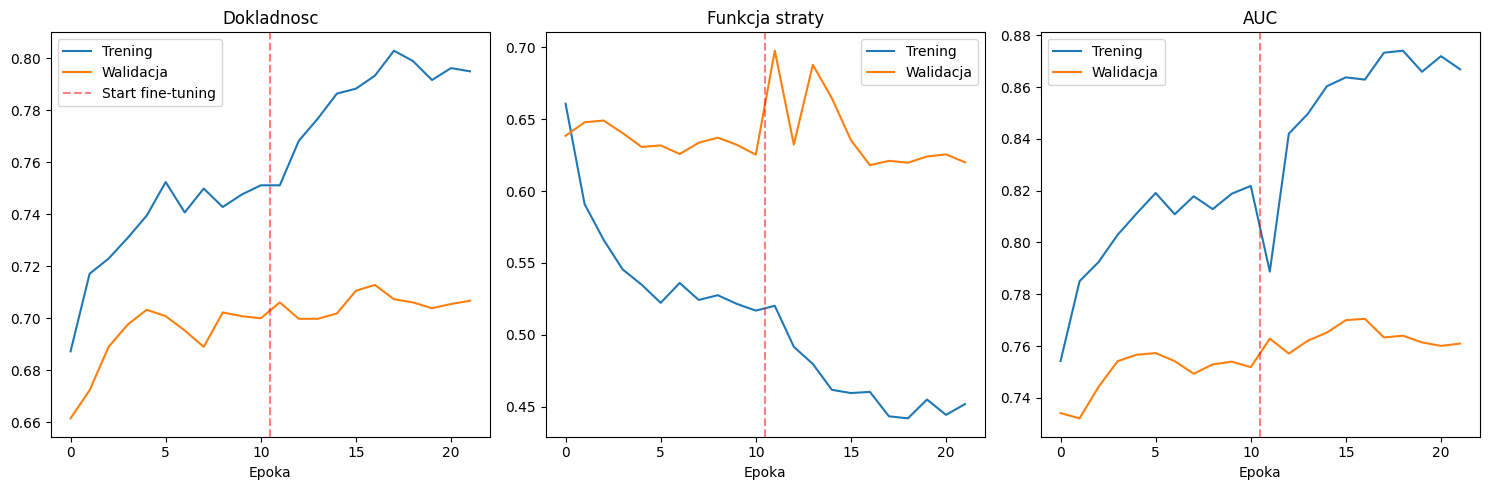

In [8]:
acc = history_full["accuracy"]
val_acc = history_full["val_accuracy"]
loss = history_full["loss"]
val_loss = history_full["val_loss"]
val_auc = history_full.get("val_auc", [])
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label="Trening")
plt.plot(epochs_range, val_acc, label="Walidacja")
plt.axvline(n_stage1 - 0.5, color="red", linestyle="--", alpha=0.5, label="Start fine-tuning")
plt.title("Dokladnosc")
plt.xlabel("Epoka")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label="Trening")
plt.plot(epochs_range, val_loss, label="Walidacja")
plt.axvline(n_stage1 - 0.5, color="red", linestyle="--", alpha=0.5)
plt.title("Funkcja straty")
plt.xlabel("Epoka")
plt.legend()

plt.subplot(1, 3, 3)
if val_auc:
    plt.plot(epochs_range, history_full["auc"], label="Trening")
    plt.plot(epochs_range, val_auc, label="Walidacja")
    plt.axvline(n_stage1 - 0.5, color="red", linestyle="--", alpha=0.5)
plt.title("AUC")
plt.xlabel("Epoka")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join("output", "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()

154/154 ━━━━━━━━━━━━━━━━━━━━ 88s 571ms/step


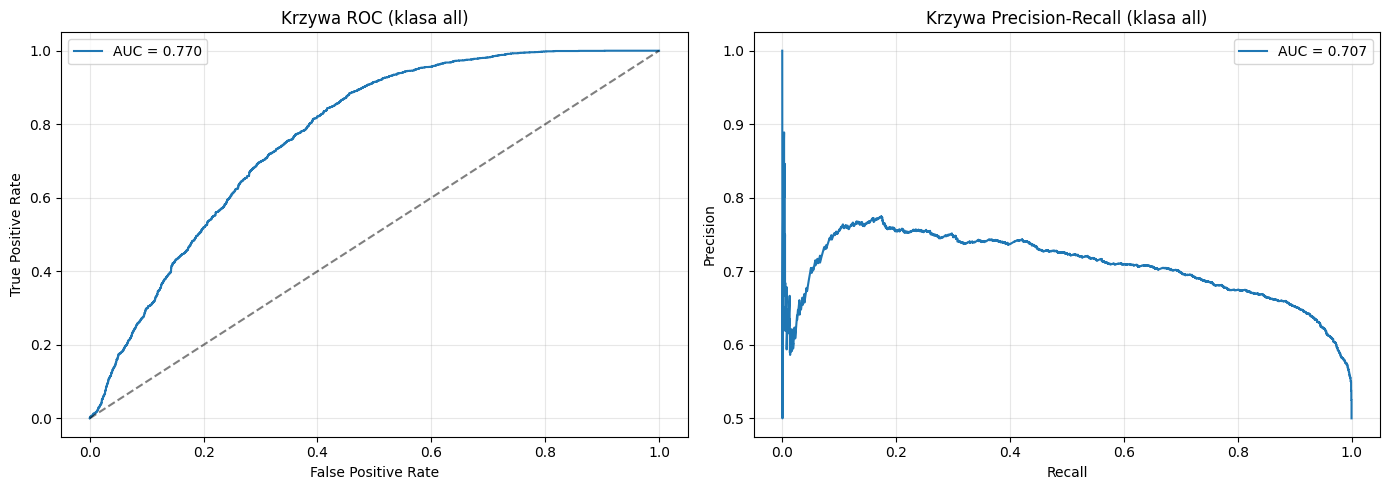

ROC AUC = 0.7705
PR  AUC = 0.7073


In [9]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc as sk_auc, precision_recall_curve, f1_score,
)

# ---- Predykcje na walidacji ----
y_pred_prob = model.predict(val_ds_prepared).flatten()
y_true = np.concatenate([y.numpy() for _, y in val_ds_prepared], axis=0).astype(int).flatten()


# ---- Krzywa ROC i Precision-Recall ----
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = sk_auc(fpr, tpr)

precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_pred_prob)
pr_auc = sk_auc(recalls, precisions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Krzywa ROC (klasa all)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(recalls, precisions, label=f"AUC = {pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Krzywa Precision-Recall (klasa all)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("output", "roc_pr_curves.png"), dpi=100, bbox_inches="tight")
plt.show()

print(f"ROC AUC = {roc_auc:.4f}")
print(f"PR  AUC = {pr_auc:.4f}")

### Optymalizacja progu decyzyjnego

Domyslny prog 0.5 jest sub-optymalny przy niezbalansowanym zbiorze (~31% hem, ~69% all) - klasa wiekszosciowa "ciagnie" predykcje w gore, przez co recall klasy `hem` jest niski. Szukamy progu maksymalizujacego **macro-F1** (srednia F1 obu klas), aby polepszyc wykrywanie klasy mniejszosciowej.

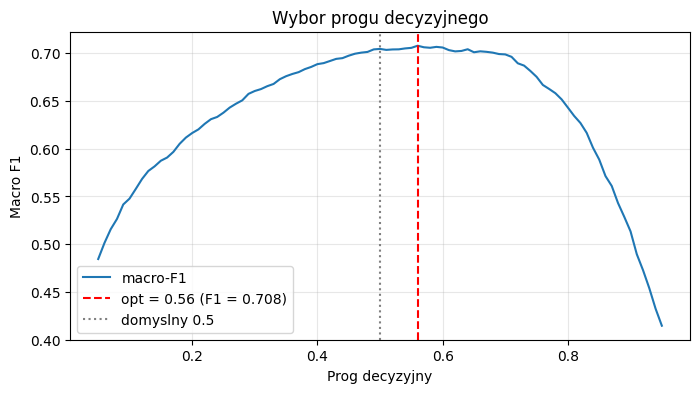

Optymalny prog: 0.560  |  macro-F1: 0.7079


In [10]:
# ---- Szukanie progu maksymalizujacego macro-F1 ----
candidate_thresholds = np.linspace(0.05, 0.95, 91)
macro_f1_scores = []
for t in candidate_thresholds:
    y_t = (y_pred_prob >= t).astype(int)
    macro_f1_scores.append(f1_score(y_true, y_t, average="macro"))

best_idx = int(np.argmax(macro_f1_scores))
best_threshold = float(candidate_thresholds[best_idx])
best_macro_f1 = float(macro_f1_scores[best_idx])

plt.figure(figsize=(8, 4))
plt.plot(candidate_thresholds, macro_f1_scores, label="macro-F1")
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"opt = {best_threshold:.2f} (F1 = {best_macro_f1:.3f})")
plt.axvline(0.5, color="gray", linestyle=":", label="domyslny 0.5")
plt.xlabel("Prog decyzyjny")
plt.ylabel("Macro F1")
plt.title("Wybor progu decyzyjnego")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join("output", "threshold_tuning.png"), dpi=100, bbox_inches="tight")
plt.show()

print(f"Optymalny prog: {best_threshold:.3f}  |  macro-F1: {best_macro_f1:.4f}")

### Macierze pomylek i raporty klasyfikacji

Porownujemy wyniki dla **domyslnego progu 0.5** oraz **progu zoptymalizowanego pod macro-F1**. Dla niezbalansowanego zbioru, gdzie klasa `hem` stanowi tylko ~31% walidacji, prog 0.5 jest zazwyczaj sub-optymalny - model "ciagnie" predykcje w strone klasy wiekszosciowej (`all`).

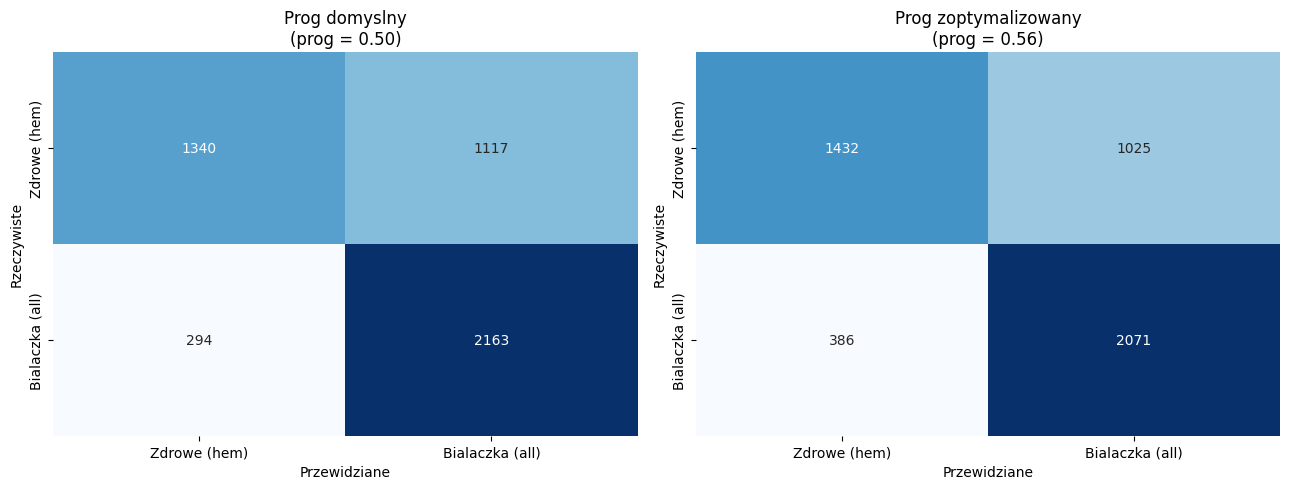

DOMYSLNY PROG = 0.50
                 precision    recall  f1-score   support

   Zdrowe (hem)      0.820     0.545     0.655      2457
Bialaczka (all)      0.659     0.880     0.754      2457

       accuracy                          0.713      4914
      macro avg      0.740     0.713     0.705      4914
   weighted avg      0.740     0.713     0.705      4914

OPTYMALNY PROG = 0.56
                 precision    recall  f1-score   support

   Zdrowe (hem)      0.788     0.583     0.670      2457
Bialaczka (all)      0.669     0.843     0.746      2457

       accuracy                          0.713      4914
      macro avg      0.728     0.713     0.708      4914
   weighted avg      0.728     0.713     0.708      4914



In [11]:
def show_confusion(threshold, title, ax):
    y_pred = (y_pred_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Zdrowe (hem)", "Bialaczka (all)"],
        yticklabels=["Zdrowe (hem)", "Bialaczka (all)"],
        ax=ax, cbar=False,
    )
    ax.set_xlabel("Przewidziane")
    ax.set_ylabel("Rzeczywiste")
    ax.set_title(f"{title}\n(prog = {threshold:.2f})")
    return y_pred


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
y_pred_default = show_confusion(0.5, "Prog domyslny", axes[0])
y_pred_opt = show_confusion(best_threshold, "Prog zoptymalizowany", axes[1])
plt.tight_layout()
plt.savefig(os.path.join("output", "confusion_matrices.png"), dpi=100, bbox_inches="tight")
plt.show()

print("=" * 65)
print(f"DOMYSLNY PROG = 0.50")
print("=" * 65)
print(classification_report(
    y_true, y_pred_default,
    target_names=["Zdrowe (hem)", "Bialaczka (all)"],
    digits=3,
))

print("=" * 65)
print(f"OPTYMALNY PROG = {best_threshold:.2f}")
print("=" * 65)
print(classification_report(
    y_true, y_pred_opt,
    target_names=["Zdrowe (hem)", "Bialaczka (all)"],
    digits=3,
))

## Dyskusja wynikow

Najwazniejsze do oceny medycznej:

- **Recall klasy `all`** (bialaczka) - jakiego odsetka chorych komorek nie wykrylismy. **False negative** (chore zakwalifikowane jako zdrowe) sa najkosztowniejszym bledem diagnostycznym.
- **Recall klasy `hem`** - poprzednio (0.59) bardzo niski; po wprowadzeniu augmentacji + fine-tuningu + tuningu progu powinien znaczaco wzrosnac.
- **AUC ROC i PR** - oceniaja jakosc rankingu prawdopodobienstw niezaleznie od wybranego progu. To bardziej stabilna miara niz accuracy przy niezbalansowanym zbiorze.
- **Wybor progu**: krzywa F1 vs prog pokazuje, ze obnizenie progu z 0.5 zwieksza recall `all` kosztem precision, a podwyzszenie polepsza klase `hem`. Optymalny prog (macro-F1) to kompromis.

**Wprowadzone usprawnienia w stosunku do wersji bazowej:**
1. Augmentacja (flip H/V, rotacja, zoom, translacja) - mocno redukuje przeuczanie.
2. Dwustopniowy trening: warm-up glowy + fine-tuning bloku 5 VGG16.
3. Glebsza glowa z BatchNorm i wyzszym dropout.
4. Wagi klas + tuning progu decyzyjnego - kompensuja niezbalansowanie.
5. Re-shuffling co epoke + dodatkowe metryki (AUC/Precision/Recall).

## Podsumowanie i wnioski

- Zastosowano transfer learning (VGG16 pre-trenowany na ImageNet) z dwuetapowym treningiem: warm-up glowy + fine-tuning bloku 5.
- Zbior treningowy: `data/fold_0/fold_0`, walidacyjny: `data/fold_2/fold_2`. Fold 1 pozostaje jako rezerwa testowa.
- Pipeline: Reinhard stain normalization + CLAHE (kanal L LAB) + augmentacja geometryczna w modelu.
- Niezbalansowanie zbioru kompensowane na trzy sposoby: wagami klas, augmentacja oraz tuningiem progu decyzyjnego.
- Wlasciwe metryki: ROC AUC, PR AUC oraz macro-F1 - nie sama accuracy.

**Kierunki dalszego rozwoju:**
- Polaczenie `fold_0 + fold_1` jako wiekszy zbior treningowy.
- Eksperyment z `EfficientNetB0`/`ResNet50` zamiast VGG16.
- `Focal loss` jako alternatywa dla weighted BCE.
- Test-time augmentation (TTA).

## Bibliografia

- [Źródło danych](https://www.kaggle.com/datasets/avk256/cnmc-leukemia/data)
- [Dokumentacja TensorFlow / Keras](https://www.tensorflow.org/api_docs)
- [VGG16 – Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556)
- [Dokumentacja biblioteki "NumPy"](https://numpy.org/doc/)
- [Dokumentacja biblioteki "matplotlib"](https://matplotlib.org/stable/index.html)
- [Dokumentacja biblioteki "seaborn"](https://seaborn.pydata.org/)
- [Dokumentacja biblioteki "scikit-learn"](https://scikit-learn.org/stable/documentation.html)